In [1]:
import jax
import jax.numpy as jnp
from jax import value_and_grad, jit, vmap
import openmm.app as apps
import openmm.unit as unit

from dmff import Hamiltonian, NeighborList
from dmff.api.xmlio import XMLIO
from dmff.api.paramset import ParamSet
from dmff.operators.templatetype import TemplateATypeOperator
import dmff
from dmff.generators.classical import PeriodicTorsionGenerator

import copy
import matplotlib.pyplot as plt
import numpy as np

from imolcryff.molinfo import load_molinfo

/Users/srak/.local/lib/python3.12/site-packages/dmff/admp/qeq.py:33: UserWarning: jaxopt not found, QEQ cannot be used.
  warnings.warn("jaxopt not found, QEQ cannot be used.")


In [2]:
class PeriodicTorsionGenerator_rev(PeriodicTorsionGenerator):
    def overwrite(self, paramset):
        # paramset to ffinfo
        proper_node_indices = [i for i in range(len(
            self.ffinfo["Forces"][self.name]["node"])) if self.ffinfo["Forces"][self.name]["node"][i]["name"] == "Proper"]
        improper_node_indices = [i for i in range(len(
            self.ffinfo["Forces"][self.name]["node"])) if self.ffinfo["Forces"][self.name]["node"][i]["name"] == "Improper"]

        proper_phase = paramset[self.name]["proper_phase"]
        proper_k = paramset[self.name]["proper_k"]
        proper_msks = paramset.mask[self.name]["proper_k"]
        for nnode, key in enumerate(self.proper_keys):
            self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]]["attrib"] = {
            }
            self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}1"] = key[0]
            self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}2"] = key[1]
            self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}3"] = key[2]
            self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}4"] = key[3]
            for nitem, item in enumerate(self.proper_key_to_prms[nnode]):
                phase, k = proper_phase[item], proper_k[item]
                mask = proper_msks[item]
                self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                         ]["attrib"]["periodicity" + str(nitem + 1)] = str(self.proper_periods[item])
                self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                         ]["attrib"]["phase" + str(nitem + 1)] = str(phase)
                self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                         ]["attrib"]["k" + str(nitem + 1)] = str(k)
            if mask < 0.999:
                self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
                                                         ]["attrib"]["mask"] = "true"

        improper_phase = paramset[self.name]["improper_phase"]
        improper_k = paramset[self.name]["improper_k"]
        improper_msks = paramset.mask[self.name]["improper_k"]
        for nnode, key in enumerate(self.imp_keys):
            self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]]["attrib"] = {
            }
            self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}1"] = key[0]
            self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}2"] = key[1]
            self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}3"] = key[2]
            self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                     ]["attrib"][f"{self.key_type}4"] = key[3]
            for nitem, item in enumerate(self.imp_key_to_prms[nnode]):
                phase = improper_phase[item]
                k = improper_k[item]
                mask = improper_msks[item]
                self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                         ]["attrib"]["periodicity" + str(nitem + 1)] = str(self.imp_periods[item])
                self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                         ]["attrib"]["phase" + str(nitem + 1)] = str(phase)
                self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                         ]["attrib"]["k" + str(nitem + 1)] = str(k)
            if mask < 0.999:
                self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
                                                         ]["attrib"]["mask"] = "true"

In [3]:
ff = Hamiltonian("gaffxml_0.xml")
molinfo = load_molinfo("mol_info.pkl")
mmm = molinfo.get_molecule_omm()
top = mmm[0].to_topology().to_openmm()
potentials = ff.createPotential(top)
efunc = potentials.getPotentialFunc()

io = XMLIO()
io.loadXML("gaffxml_0.xml")
ffinfo = io.parseXML()
topdata = dmff.DMFFTopology(top)
operator = TemplateATypeOperator(ffinfo)
operator.operate(topdata)
for na, a in enumerate(topdata._meta):
    print(a)
paramset_dihed = ParamSet()
torsion_gen = PeriodicTorsionGenerator(ffinfo, paramset_dihed)

[02:28:20] atom 10 has specified valence (1) smaller than the drawn valence 2.


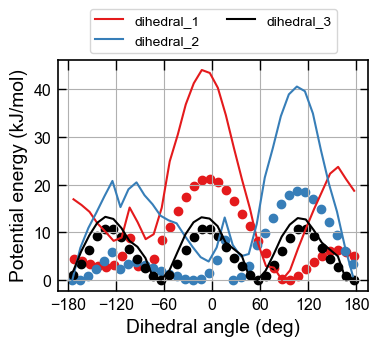

In [4]:
from imolcryff.molinfo import draw_dihedral_plots
gt, ff_scan = draw_dihedral_plots(molinfo, "MOL_0")

In [5]:
@jit
def MSELoss(params0: ParamSet, ffparams, positions, box, pairs, gt_Etot):
    kT = 2.494 # 300 K = 2.494 kJ/mol
    assert len(positions) == len(gt_Etot)
    assert len(positions) == len(pairs)
    
    gt_Etot = gt_Etot - gt_Etot.min()
    gt_Etot = jnp.array(gt_Etot)
    weights_pts = jnp.piecewise(gt_Etot, [gt_Etot<25, gt_Etot>=25], [lambda x: jnp.array(1.0), lambda x: jnp.exp(-(x-25)/kT)])
    npts = len(weights_pts)
    
    # setting up params for all calculators
    params_dihed = {} 
    params_dihed["PeriodicTorsionForce"] = {}
    params_dihed["PeriodicTorsionForce"]["proper_phase"] = params0["PeriodicTorsionForce"]["proper_phase"]
    params_dihed["PeriodicTorsionForce"]["proper_k"] = params0["PeriodicTorsionForce"]["proper_k"]

    p = copy.deepcopy(ffparams)
    p['PeriodicTorsionForce']["proper_phase"] = params_dihed["PeriodicTorsionForce"]["proper_phase"]
    p['PeriodicTorsionForce']["proper_k"] = params_dihed["PeriodicTorsionForce"]["proper_k"]

    # calculate each points, only the short range and damping components
    totene_ff = jnp.zeros(npts)
    for ipt in range(npts):
        totene_ff = totene_ff.at[ipt].set(efunc(positions[ipt], box, pairs[ipt], p))
    
    totene_ff = totene_ff - totene_ff.min()
        
    dE = totene_ff - gt_Etot
    mse = dE**2 * weights_pts / jnp.sum(weights_pts)
    mse = jnp.sum(mse)

    return mse

In [6]:
def get_pospairs_dihedral(dihedral_aseatoms_list, dihed_idx):
    dihed_ase = dihedral_aseatoms_list[dihed_idx]

    box = jnp.array([
            [1000.0,  0.0,  0.0],
            [ 0.0, 1000.0,  0.0],
            [ 0.0,  0.0, 1000.0]
        ])

    jnp_positions = jnp.array([jnp.array(dihed_ase[i].positions / 10) for i in range(len(dihed_ase))])
    jnp_pairs= []

    for i_dihed in range(len(dihed_ase)):
        nbList = NeighborList(box, rcut=40, cov_map=potentials.meta["cov_map"])
        nbList.allocate(jnp_positions[i_dihed])
        jnp_pairs.append(nbList.pairs)

    jnp_pairs = jnp.array(jnp_pairs)

    return jnp_positions, box, jnp_pairs

def get_gt_Etot(molinfo, molname, idx):
    from ase import units
    gt_Etot = molinfo.mol_info[molname]["dihedral_energy"][idx]
    gt_Etot = (gt_Etot - gt_Etot.min()) / (units.kJ * (units.mol**-1))
    gt_Etot = jnp.array(gt_Etot)
    return gt_Etot

In [7]:
ff.getParameters().to_jax()
paramset0 = ff.getParameters()
paramset0

In [8]:
jnp_positions, jnp_box, jnp_pairs = get_pospairs_dihedral(molinfo.mol_info["MOL_0"]["dihedral_aseatoms"], 1)
dihedral_qm = get_gt_Etot(molinfo, "MOL_0", 1)
a = MSELoss(paramset0, paramset0, jnp_positions, jnp_box, jnp_pairs, dihedral_qm)

In [9]:
MSELoss_grad = jit(value_and_grad(MSELoss, argnums=(0)))
err, gradients = MSELoss_grad(paramset0, paramset0, jnp_positions, jnp_box, jnp_pairs, dihedral_qm)

In [10]:
def add_grad(grad1:ParamSet, grad2:ParamSet):
    for k in grad1.parameters.keys():
        for t in grad1.parameters[k].keys():
            grad1.parameters[k][t] += grad2.parameters[k][t]
    return ParamSet(grad1.parameters, grad1.mask)

In [11]:
import optax
import sys
# start to do optmization


lr = 0.01
opt = optax.adam(lr)

opt_state = opt.init(paramset_dihed)

jnp_positions_list = []
jnp_box_list = []
jnp_pairs_list = []
dihedral_qm_list = []
for i, i_dihed in enumerate([1,2,3]):
    jnp_positions, jnp_box, jnp_pairs = get_pospairs_dihedral(molinfo.mol_info["MOL_0"]["dihedral_aseatoms"], i_dihed)
    dihedral_qm = get_gt_Etot(molinfo, "MOL_0", i_dihed)
    jnp_positions_list.append(jnp_positions)
    jnp_box_list.append(jnp_box)
    jnp_pairs_list.append(jnp_pairs)
    dihedral_qm_list.append(dihedral_qm)

n_epochs = 200000
best_loss = 1e10
for i_epoch in range(1,n_epochs+1):
    for i, i_dihed in enumerate([1,2,3]):
        loss_tmp, grads_tmp = MSELoss_grad(paramset_dihed, paramset0, jnp_positions_list[i], jnp_box_list[i], jnp_pairs_list[i], dihedral_qm_list[i])
        if i == 0:
            loss = loss_tmp
            grads = grads_tmp
        else:
            loss += loss_tmp
            grads = add_grad(grads, grads_tmp)

    if loss < best_loss:
        best_loss = loss
        best_params = paramset_dihed
    sys.stdout.flush()
    # updates, opt_state = opt.update(grads, opt_state, value=loss)
    updates, opt_state = opt.update(grads, opt_state)
    paramset_dihed = optax.apply_updates(paramset_dihed, updates)
    # paramset_dihed = jax.tree_map(lambda x: jnp.clip(x, 0.0, 1e8), paramset_dihed)
    torsion_gen.overwrite(paramset_dihed)

    if i_epoch % 100 == 0:
        print(f"epoch: {i_epoch}, loss: {loss}")
    if i_epoch % 10000 == 0:
        io.writeXML(f"loop-{i_epoch}.xml", ffinfo)

epoch: 100, loss: 112.30021537028435
epoch: 200, loss: 48.67187800876196
epoch: 300, loss: 22.556692836678504
epoch: 400, loss: 20.77258652908873
epoch: 500, loss: 20.568785363301945
epoch: 600, loss: 20.42315027041496
epoch: 700, loss: 20.31205927442096
epoch: 800, loss: 20.24596422428852
epoch: 900, loss: 20.126273305724524
epoch: 1000, loss: 19.893854641387225
epoch: 1100, loss: 19.598674485768473
epoch: 1200, loss: 19.348151176951017
epoch: 1300, loss: 19.136428096269213
epoch: 1400, loss: 18.953758514081233
epoch: 1500, loss: 18.798545673190375
epoch: 1600, loss: 18.663435898360714
epoch: 1700, loss: 18.548967897227623
epoch: 1800, loss: 18.4571577438849
epoch: 1900, loss: 18.388656875325587
epoch: 2000, loss: 18.333695596695026
epoch: 2100, loss: 18.266226458215204
epoch: 2200, loss: 18.252596395660166
epoch: 2300, loss: 18.173855300218715
epoch: 2400, loss: 18.133745473089785
epoch: 2500, loss: 18.104293309050764
epoch: 2600, loss: 18.08373001324758
epoch: 2700, loss: 18.0348495

In [21]:
import pickle
with open('params.pickle', 'wb') as ofile:
    pickle.dump(best_params, ofile)

In [22]:
import pickle
with open('params.pickle',"rb") as ofile:
    best_params = pickle.load(ofile)

torsion_gen.overwrite(best_params)
io.writeXML("best.xml", ffinfo)

In [23]:
def ff_dihed(id, params):
    dihed_ase = molinfo.mol_info["MOL_0"]["dihedral_aseatoms"][id]
    totenes = []
    for i_dihed in range(len(dihed_ase)):
        positions = jnp.array(dihed_ase[i_dihed].positions / 10)
        box = jnp.array([
            [1000.0,  0.0,  0.0],
            [ 0.0, 1000.0,  0.0],
            [ 0.0,  0.0, 1000.0]
        ])
        nbList = NeighborList(box, rcut=40, cov_map=potentials.meta["cov_map"])
        nbList.allocate(positions)
        pairs = nbList.pairs
        efunc = potentials.getPotentialFunc()
        totene = efunc(positions, box, pairs, params)
        totenes.append(totene)
    totenes = np.array(totenes)
    return totenes

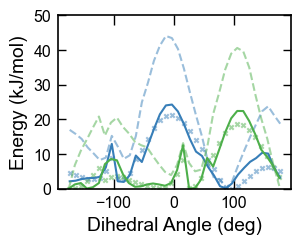

In [24]:
cmap = plt.get_cmap('Set1')
from ase import units
best_params = Hamiltonian("best.xml").getParameters()
plt.ylim(0, 50)
plt.xlabel("Dihedral Angle (deg)")
plt.ylabel("Energy (kJ/mol)")
for id in range(1,3):
    totenes = ff_dihed(id, best_params)
    totenes = totenes - totenes.min()
    dihed = molinfo.mol_info["MOL_0"]["dihedral_angle"][id]
    plt.plot(dihed,totenes,color=cmap(id))
    # gt = (molinfo.mol_info["MOL_0"]["dihedral_energy"][id] - molinfo.mol_info["MOL_0"]["dihedral_energy"][id].min()) / (units.kJ * (units.mol**-1))
    plt.scatter(dihed, gt[id],color=cmap(id),marker='x',s=10,alpha=0.5)
    plt.plot(dihed, ff_scan[id],color=cmap(id),alpha=0.5,linestyle='--')

In [16]:
# from dmff.api.xmlio import XMLIO
# from dmff.api.paramset import ParamSet
# from dmff.operators.templatetype import TemplateATypeOperator
# import dmff
# from dmff.generators.classical import PeriodicTorsionGenerator

# io = XMLIO()
# io.loadXML("gaffxml_0.xml")
# ffinfo = io.parseXML()

In [17]:
# import xml.etree.ElementTree as ET

# def xmlrender(file1, file2, file3):
#     """
#     file1: torsion.xml
#     file2: res.xml
#     file3: output.xml
#     """
#     torsion_tree = ET.parse(file1)
#     torsion_root = torsion_tree.getroot()

#     fullff_tree = ET.parse(file2)
#     fullff_root = fullff_tree.getroot()

#     fullff_torsion_force_element = fullff_root.find(".//PeriodicTorsionForce")

#     torsion_force_element = torsion_root.find(".//PeriodicTorsionForce")

#     for atom_element in torsion_force_element:
#         fullff_torsion_force_element.append(atom_element)
        
#     combined_tree = ET.ElementTree(fullff_root)
#     combined_tree.write(file3, encoding='utf-8')

In [18]:
# class PeriodicTorsionGenerator_rev(PeriodicTorsionGenerator):
#     def overwrite(self, paramset):
#         # paramset to ffinfo
#         proper_node_indices = [i for i in range(len(
#             self.ffinfo["Forces"][self.name]["node"])) if self.ffinfo["Forces"][self.name]["node"][i]["name"] == "Proper"]
#         improper_node_indices = [i for i in range(len(
#             self.ffinfo["Forces"][self.name]["node"])) if self.ffinfo["Forces"][self.name]["node"][i]["name"] == "Improper"]

#         proper_phase = paramset[self.name]["proper_phase"]
#         proper_k = paramset[self.name]["proper_k"]
#         proper_msks = paramset.mask[self.name]["proper_k"]
#         for nnode, key in enumerate(self.proper_keys):
#             self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]]["attrib"] = {
#             }
#             self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}1"] = key[0]
#             self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}2"] = key[1]
#             self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}3"] = key[2]
#             self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}4"] = key[3]
#             for nitem, item in enumerate(self.proper_key_to_prms[nnode]):
#                 phase, k = proper_phase[item], proper_k[item]
#                 mask = proper_msks[item]
#                 self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                          ]["attrib"]["periodicity" + str(nitem + 1)] = str(self.proper_periods[item])
#                 self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                          ]["attrib"]["phase" + str(nitem + 1)] = str(phase)
#                 self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                          ]["attrib"]["k" + str(nitem + 1)] = str(k)
#             if mask < 0.999:
#                 self.ffinfo["Forces"][self.name]["node"][proper_node_indices[nnode]
#                                                          ]["attrib"]["mask"] = "true"

#         improper_phase = paramset[self.name]["improper_phase"]
#         improper_k = paramset[self.name]["improper_k"]
#         improper_msks = paramset.mask[self.name]["improper_k"]
#         for nnode, key in enumerate(self.imp_keys):
#             self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]]["attrib"] = {
#             }
#             self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}1"] = key[0]
#             self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}2"] = key[1]
#             self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}3"] = key[2]
#             self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                      ]["attrib"][f"{self.key_type}4"] = key[3]
#             for nitem, item in enumerate(self.imp_key_to_prms[nnode]):
#                 phase = improper_phase[item]
#                 k = improper_k[item]
#                 mask = improper_msks[item]
#                 self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                          ]["attrib"]["periodicity" + str(nitem + 1)] = str(self.imp_periods[item])
#                 self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                          ]["attrib"]["phase" + str(nitem + 1)] = str(phase)
#                 self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                          ]["attrib"]["k" + str(nitem + 1)] = str(k)
#             if mask < 0.999:
#                 self.ffinfo["Forces"][self.name]["node"][improper_node_indices[nnode]
#                                                          ]["attrib"]["mask"] = "true"

In [19]:
# from dmff.operators.templatetype import TemplateATypeOperator
# import dmff
# from dmff.generators.classical import PeriodicTorsionGenerator
# from imolcryff.molinfo import load_molinfo

# print(dmff.__file__)
# molinfo = load_molinfo("mol_info.pkl")
# mmm = molinfo.get_molecule_omm()
# top = mmm[0].to_topology().to_openmm()
# topdata = dmff.DMFFTopology(top)

# io = XMLIO()
# io.loadXML("gaffxml_0.xml")
# ffinfo = io.parseXML()
# operator = TemplateATypeOperator(ffinfo)
# operator.operate(topdata)
# for na, a in enumerate(topdata._meta):
#     print(a)
# paramset = ParamSet()
# torsion_gen = PeriodicTorsionGenerator_rev(ffinfo, paramset)

# ####
# # paramset = optax.apply_updates(paramset, updates)

# # paramset = jax.tree_map(lambda x: jnp.clip(x, 0.0, 1e8), paramset)

# torsion_gen.overwrite(paramset)
# io.writeXML(f"loop-.xml", ffinfo)

In [20]:
# from dmff.generators.classical import NonbondedGenerator
# from dmff.operators.templatetype import TemplateATypeOperator
# import dmff

# top = mmm[0].to_topology().to_openmm()
# topdata = dmff.DMFFTopology(top)

# io = XMLIO()
# io.loadXML("gaffxml_0.xml")
# ffinfo = io.parseXML()

# paramset = ParamSet()
# torsion_gen = NonbondedGenerator(ffinfo, paramset)